# Plot correlations between SSS, density, and stratification for entire HH domain - August

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
import matplotlib
import gsw
import cmocean

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33829")
client

<Client: 'tcp://127.0.0.1:33829' processes=8 threads=32, memory=123.95 GiB>

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# initialize s3 filesystem
# for sassie s3 bucket
# s3_options = dict(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)
# for ecco s3 bucket
s3_options = dict(anon=False)

In [6]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [7]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

### Plot entire domain for reference

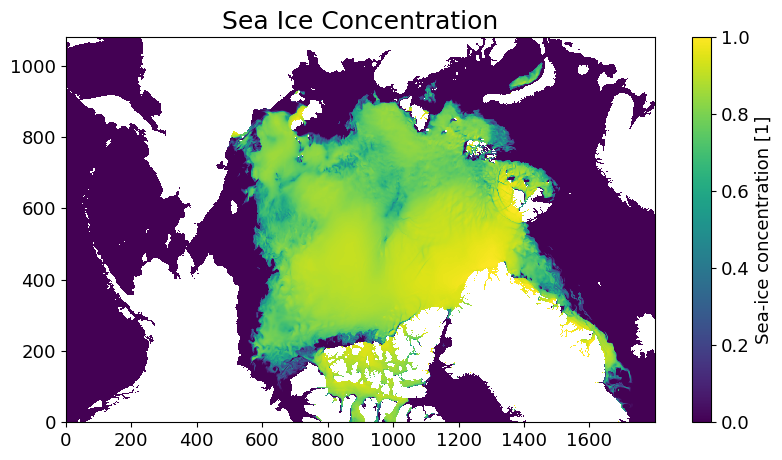

In [108]:
plt.rcParams.update({'font.size': 13})
SI_zarr.SIarea.sel(time='2019-08-15').plot(figsize=[9.5,5]);
plt.xlabel("")
plt.ylabel("")
plt.title("Sea Ice Concentration",size=18);

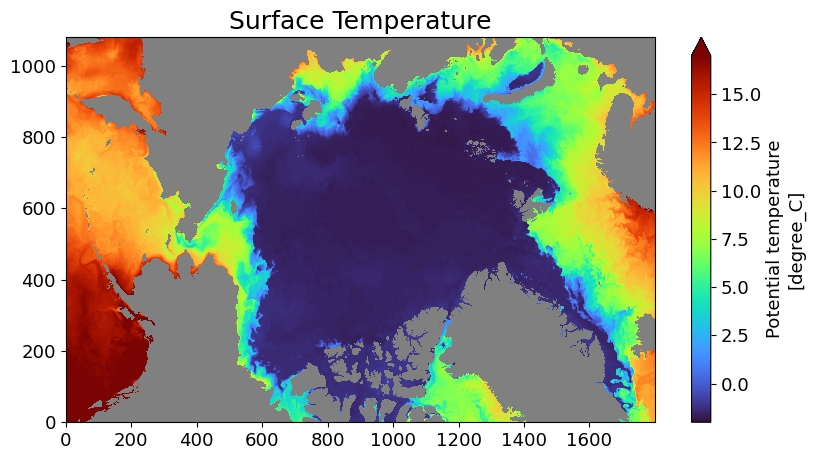

In [109]:
fig, ax = plt.subplots(figsize=[9.5,5])
THETA_zarr.THETA.sel(time='2019-08-15').isel(k=0).plot(ax=ax,cmap='turbo',vmin=-2,vmax=17);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Surface Temperature",size=18);

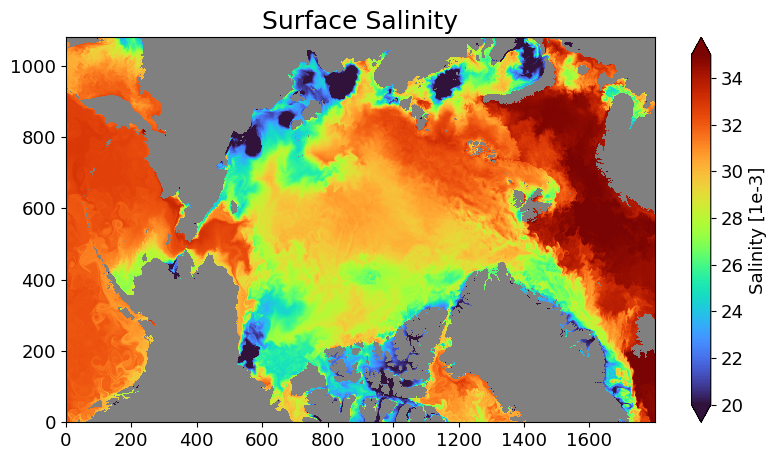

In [110]:
fig, ax = plt.subplots(figsize=[9.5,5])
SALT_zarr.SALT.sel(time='2019-08-15').isel(k=0).plot(ax=ax,cmap='turbo',vmin=20,vmax=35);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Surface Salinity",size=18);

## Calculate all quantities needed

In [8]:
# select entire month and only vertical levels we want (surface, 20, and 100 m)
date = "2019-08"
salt_month = SALT_zarr.SALT.sel(time=date).isel(k=[0,10,21])
temp_month = THETA_zarr.THETA.sel(time=date).isel(k=[0,10,21])

### Calculate potential Density

In [9]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=[0,10,21]).Z, HH_grid.YC).compute()

In [10]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,  21.30716931, 100.246103  ])

In [11]:
# Calculates Absolute Salinity from Practical Salinity
abs_salt = gsw.SA_from_SP(salt_month, pressure_da, HH_grid.XC, HH_grid.YC)

In [12]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
cons_temp = gsw.CT_from_pt(abs_salt, temp_month)

In [13]:
# calculate potential density
dens_da = gsw.density.sigma0(abs_salt, cons_temp)

# change name and clear salinity attrs
dens_da.name = 'potential_density'
dens_da.attrs = ""

## Correlation between SSS and density at the surface

First plot the density field at the surface

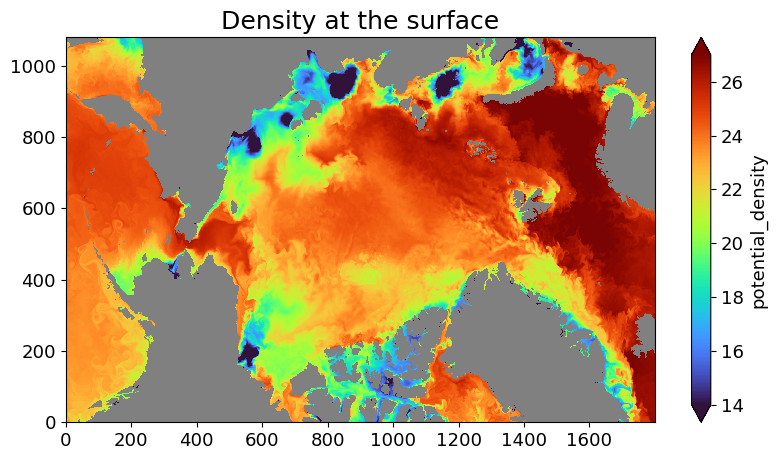

In [111]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=0).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=14,vmax=27);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at the surface",size=18);

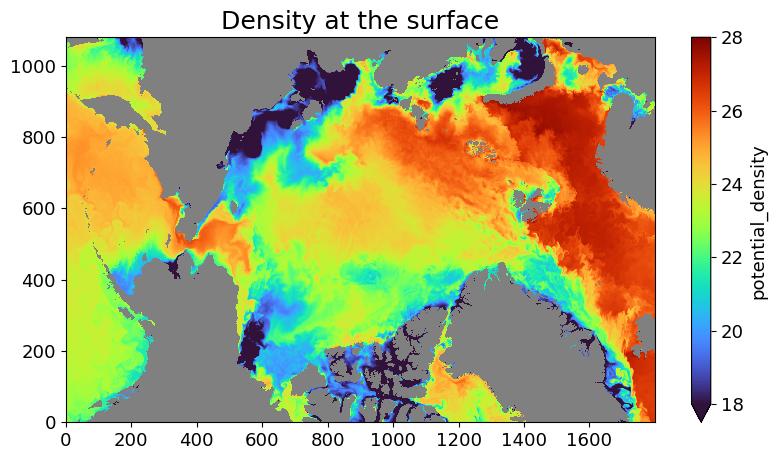

In [147]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=0).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=18,vmax=28);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at the surface",size=18);

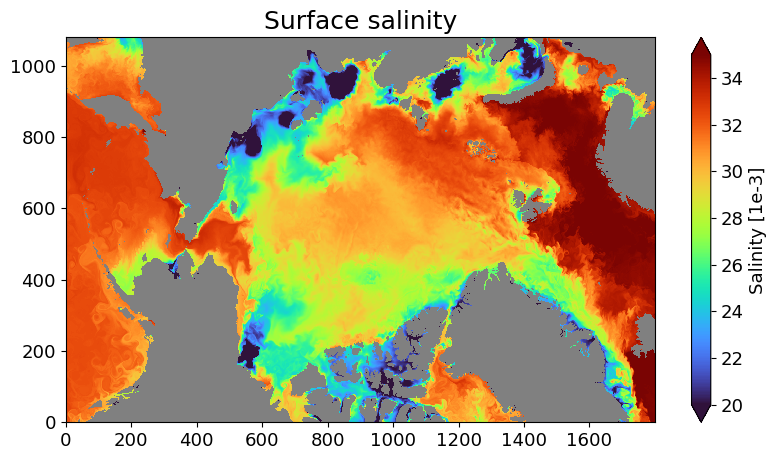

In [112]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
abs_salt.isel(k=0).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=20,vmax=35);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Surface salinity",size=18);

In [56]:
corr_surf = xr.corr(abs_salt.isel(k=0), dens_da.isel(k=0), dim='time').compute()

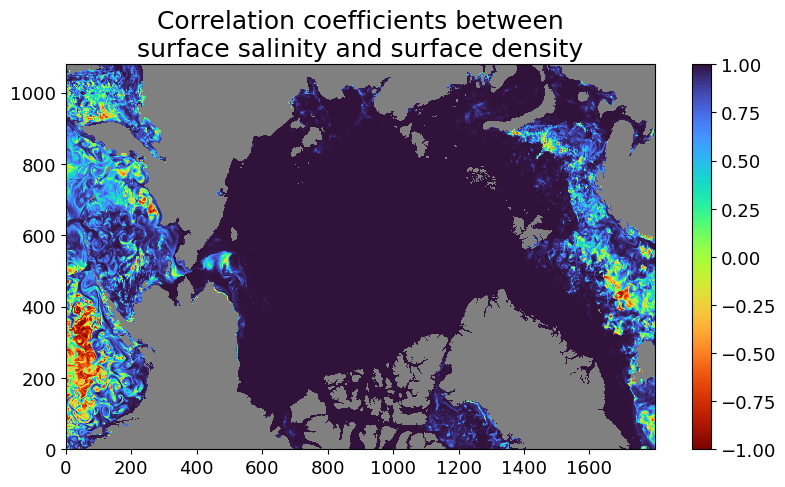

In [114]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_surf.plot(ax=ax,cmap='turbo_r');
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Correlation coefficients between\nsurface salinity and surface density",size=18);

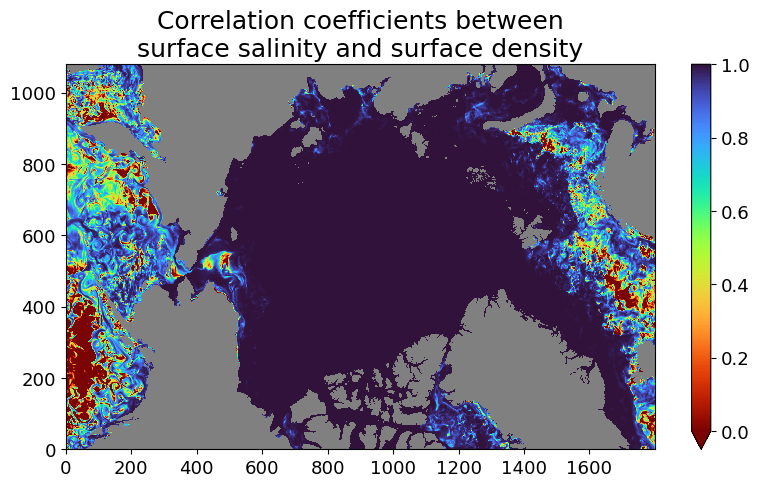

In [115]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_surf.plot(ax=ax,cmap='turbo_r',vmin=0,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Correlation coefficients between\nsurface salinity and surface density",size=18);

## Correlation between SSS and density at 20 m

First plot the density field at the surface

In [61]:
dens_da.isel(k=1).Z.values

array(-21.125, dtype=float32)

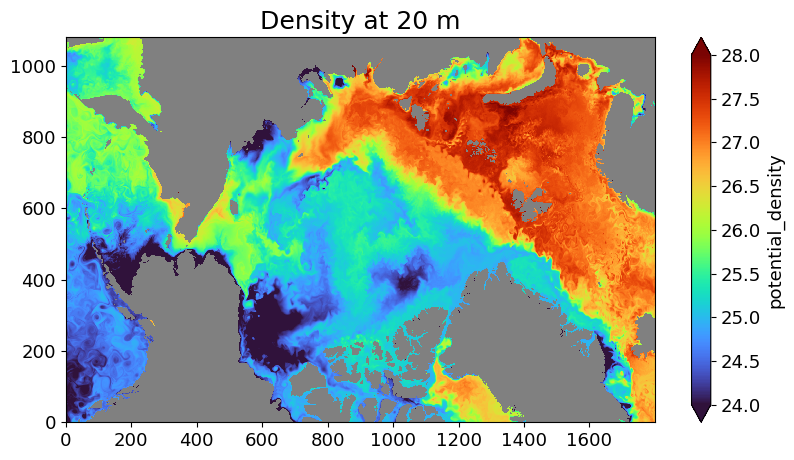

In [116]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=1).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=24,vmax=28);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at 20 m",size=18);

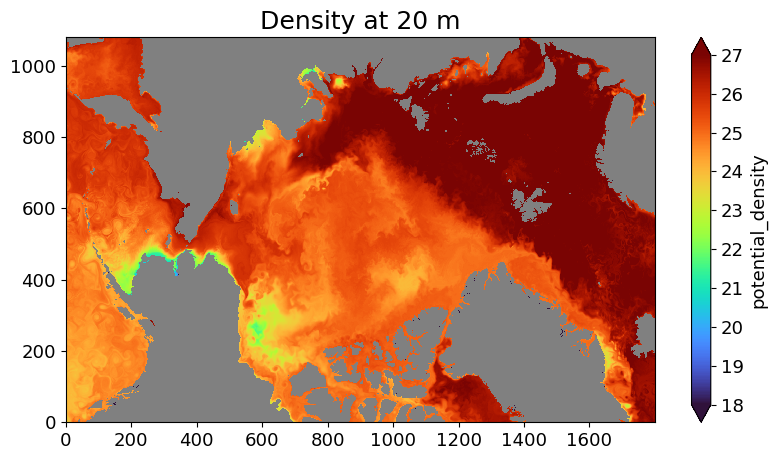

In [144]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=1).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=18,vmax=27);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at 20 m",size=18);

In [117]:
corr_20m = xr.corr(abs_salt.isel(k=0), dens_da.isel(k=1), dim='time').compute()

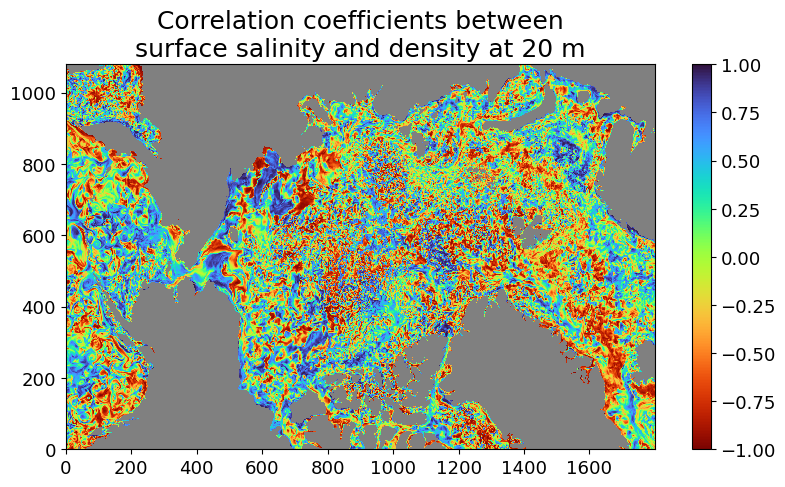

In [119]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_20m.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Correlation coefficients between\nsurface salinity and density at 20 m",size=18);

## Correlation between SSS and density at 100 m

First plot the density field at the surface

In [69]:
dens_da.isel(k=2).Z.values

array(-99.37, dtype=float32)

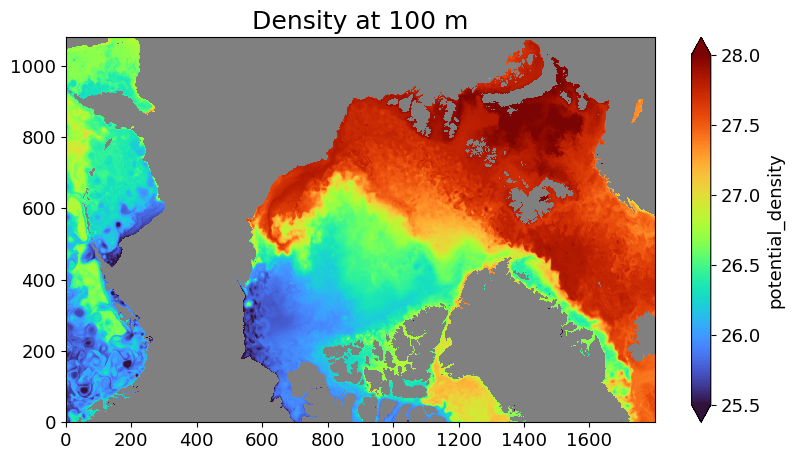

In [120]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=2).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=25.5,vmax=28);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at 100 m",size=18);

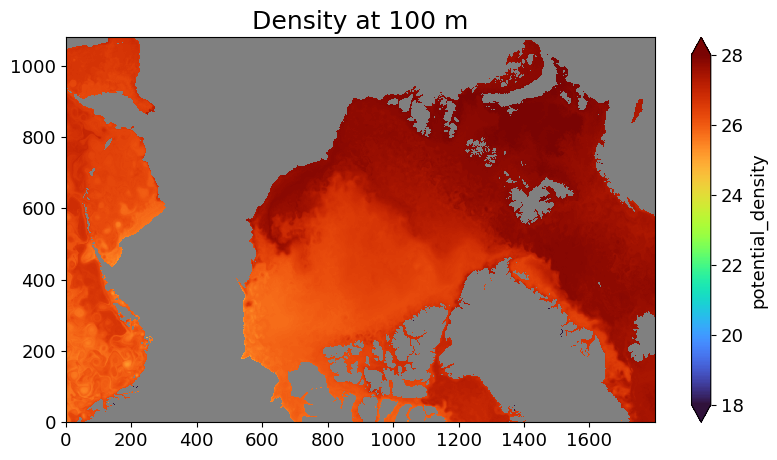

In [146]:
fig, ax = plt.subplots(figsize=[9.5,5])
dens_da.isel(k=2).sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=18,vmax=28);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Density at 100 m",size=18);

In [121]:
corr_100m = xr.corr(abs_salt.isel(k=0), dens_da.isel(k=2), dim='time').compute()

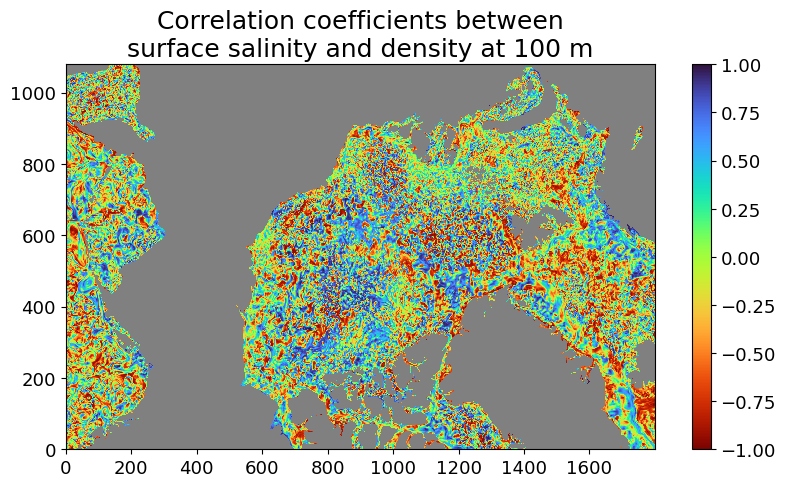

In [123]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_100m.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Correlation coefficients between\nsurface salinity and density at 100 m",size=18);

## Correlation between SSS and $\Delta \sigma_{\theta} = \sigma_{\theta, \text{surface}} - \sigma_{\theta, 20 \, \text{m}}$

First plot the density field at the surface

In [14]:
print(dens_da.isel(k=0).Z.values)
print(dens_da.isel(k=1).Z.values)

-0.5
-21.125


In [15]:
# calculate delta sigma
delta_sigma_20m = (dens_da.isel(k=0) - dens_da.isel(k=1)).compute()

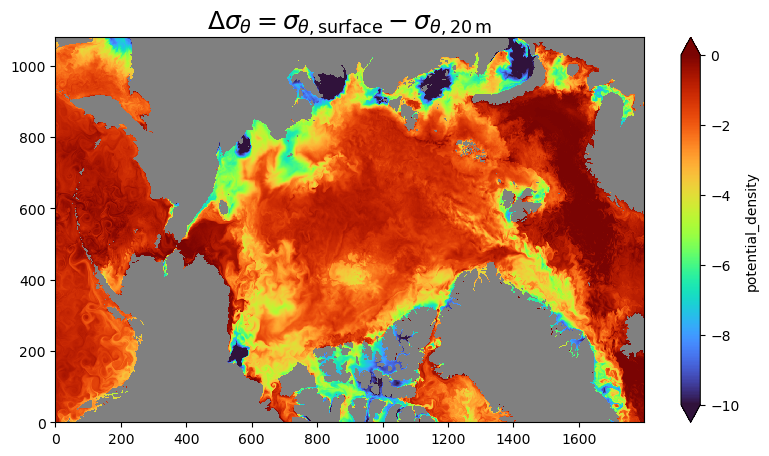

In [16]:
fig, ax = plt.subplots(figsize=[9.5,5])
delta_sigma_20m.sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=-10,vmax=0);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(r'$\Delta \sigma_{\theta} = \sigma_{\theta, \text{surface}} - \sigma_{\theta, 20 \, \text{m}}$',size=18);

In [17]:
corr_0minus20m = xr.corr(abs_salt.isel(k=0), delta_sigma_20m, dim='time').compute()

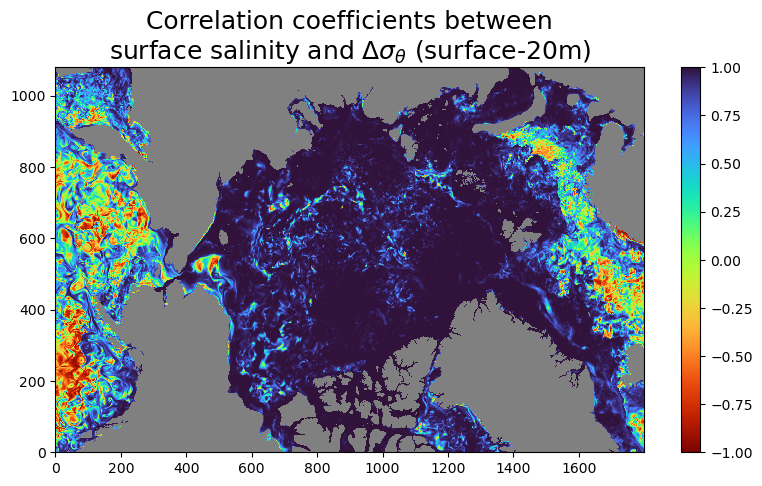

In [18]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_0minus20m.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Correlation coefficients between\nsurface salinity and ' + r'$\Delta \sigma_{\theta}$ (surface-20m)', size=18);

## Correlation between SSS and $\Delta \sigma_{0} = \sigma_{0, \text{surface}} - \sigma_{0, 100 \, \text{m}}$

First plot the density field at the surface

In [19]:
print(dens_da.isel(k=0).Z.values)
print(dens_da.isel(k=2).Z.values)

-0.5
-99.37


In [20]:
# calculate delta sigma
delta_sigma_100m = (dens_da.isel(k=0) - dens_da.isel(k=2)).compute()

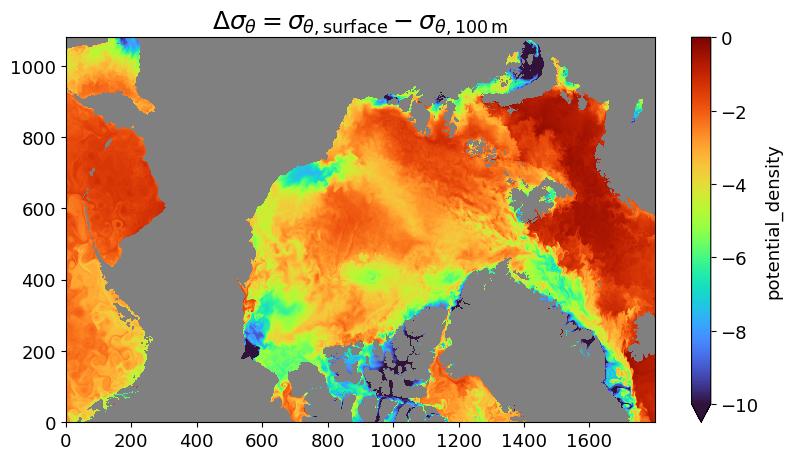

In [21]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
delta_sigma_100m.sel(time='2019-08-15').plot(ax=ax,cmap='turbo',vmin=-10,vmax=0);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(r'$\Delta \sigma_{\theta} = \sigma_{\theta, \text{surface}} - \sigma_{\theta, 100 \, \text{m}}$',size=18);

In [23]:
corr_0minus100m = xr.corr(abs_salt.isel(k=0), delta_sigma_100m, dim='time').compute()

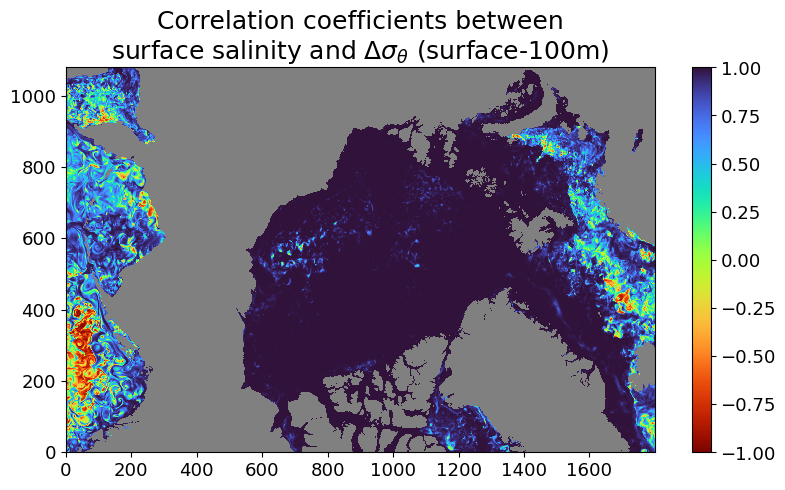

In [24]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_0minus100m.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Correlation coefficients between\nsurface salinity and ' + r'$\Delta \sigma_{\theta}$ (surface-100m)', size=18);

## Correlation between SSS and sum($N$) in upper 20 m

#### Calculate buoyancy frequency

Conversion functions: https://teos-10.github.io/GSW-Python/conversions.html

In [8]:
# select entire month and only vertical levels we want
# pull out the upper 20 m of data
date = "2019-08"
salt_month = SALT_zarr.SALT.sel(time=date).isel(k=slice(0,11))
temp_month = THETA_zarr.THETA.sel(time=date).isel(k=slice(0,11))

In [9]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=slice(0,11)).Z, HH_grid.YC).compute()

In [10]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([ 0.50428623,  1.58346296,  2.8139329 ,  4.22091377,  5.82962441,
        7.66024071,  9.74302836, 12.1132969 , 14.80635815, 17.85752767,
       21.30716931])

In [11]:
# check shape of each dataset
print(np.shape(salt_month))
print(np.shape(temp_month))
print(np.shape(pressure_da))

(31, 11, 1080, 1800)
(31, 11, 1080, 1800)
(11, 1080, 1800)


Note: opting to use practical salinity and in situ temperature here to reduce computational load since these values are effectively identical near the surface

In [12]:
import time

In [13]:
# start time
start_time = time.time()

# Brunt Vaisala Frequency (N^2)
# Buoyancy frequency-squared at pressure midpoints, 1/s^2. 
# The shape along the pressure axis dimension is one less than that of the inputs. (Frequency N is in radians per second.)
# Pressure at midpoints of p, dbar. The array shape matches N2.
# N2, p_mid = gsw.Nsquared(salt_month, temp_month, pressure_da_expanded, axis=1)
N2, p_mid = gsw.Nsquared(salt_month, temp_month, pressure_da, axis=1)

# end time
end_time = time.time()

# calculate elapsed time
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")

Execution time: 85.552708 seconds


In [14]:
N2.shape

(31, 10, 1080, 1800)

In [15]:
p_mid.shape

(31, 10, 1080, 1800)

In [16]:
# take average across whole domain
p_mid_avg = p_mid.mean(axis=(0,2,3))

In [17]:
p_mid_avg

array([ 1.04555006,  2.20222694,  3.52306898,  5.03333492,  6.75575859,
        8.71560126, 10.94570317, 13.48143171, 16.35815727, 19.6137803 ])

In [19]:
N2_da = xr.DataArray(data=N2,dims=['time','p_mid','j','i'],\
                     coords=dict(p_mid=p_mid_avg,j=salt_month.j.values,i=salt_month.i.values,time=salt_month.time.values))

In [20]:
# take sum of N over upper 20 m
N_sum20 = np.sqrt(N2_da.sum('p_mid'))

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [22]:
# take integral of N over upper 20 m
N_int20 = np.sqrt(N2_da.integrate('p_mid'))

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


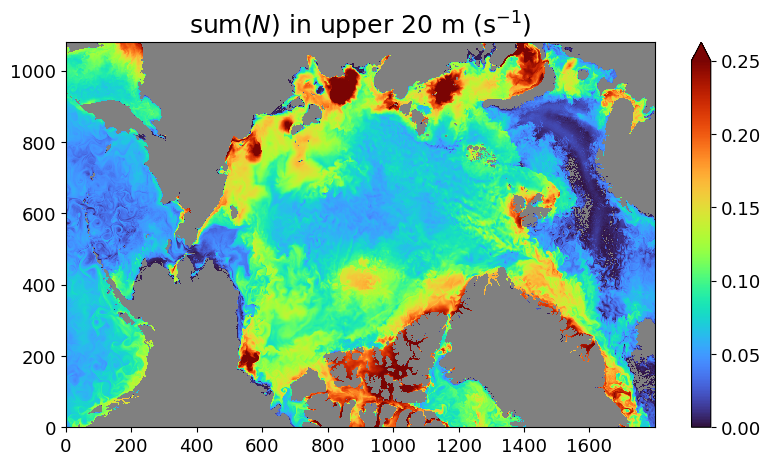

In [26]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
N_sum20.sel(time="2019-08-15").where(N_sum20.sel(time="2019-08-15")>0).plot(ax=ax,cmap='turbo', vmin=0, vmax=0.25);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("sum($N$) in upper 20 m (s$^{-1}$)",size=18);

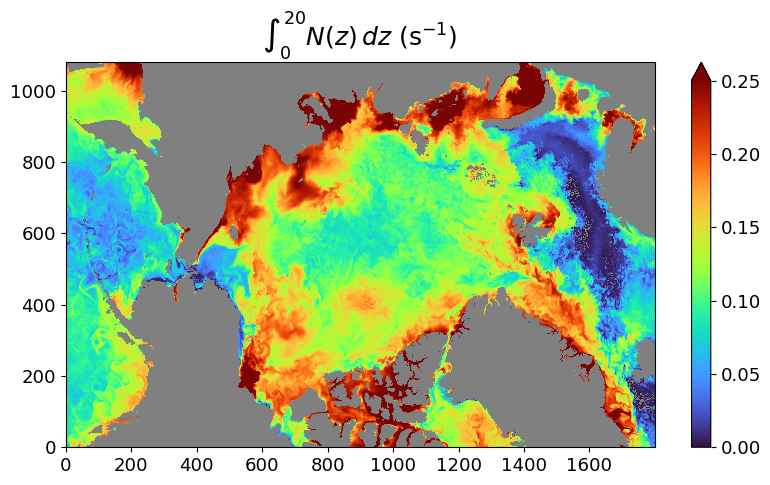

In [25]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
N_int20.sel(time="2019-08-15").plot(ax=ax,cmap='turbo', vmin=0, vmax=0.25);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(r'$\int_0^{20} N(z) \, dz$ (s$^{-1}$)',size=18);

In [224]:
# compute correlation
corr_sumN20 = xr.corr(abs_salt.isel(k=0), N_sum20, dim='time').compute()

In [34]:
# compute correlation
corr_intN20 = xr.corr(abs_salt.isel(k=0), N_int20, dim='time').compute()

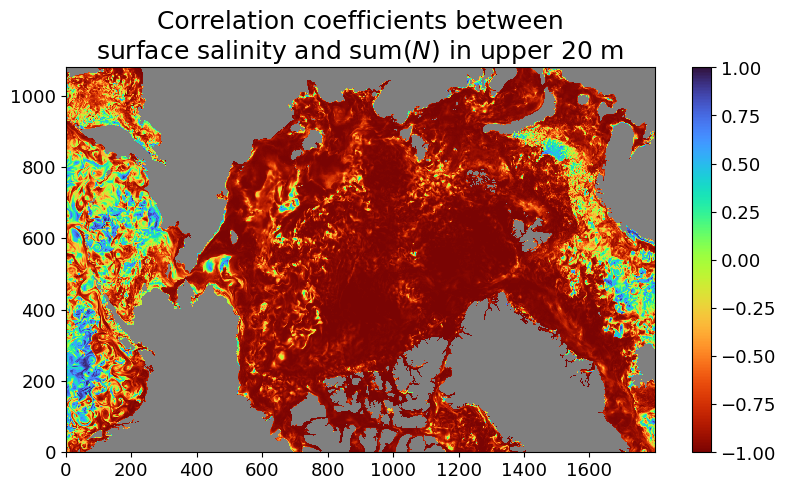

In [225]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_sumN20.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Correlation coefficients between\nsurface salinity and sum($N$) in upper 20 m', size=18);

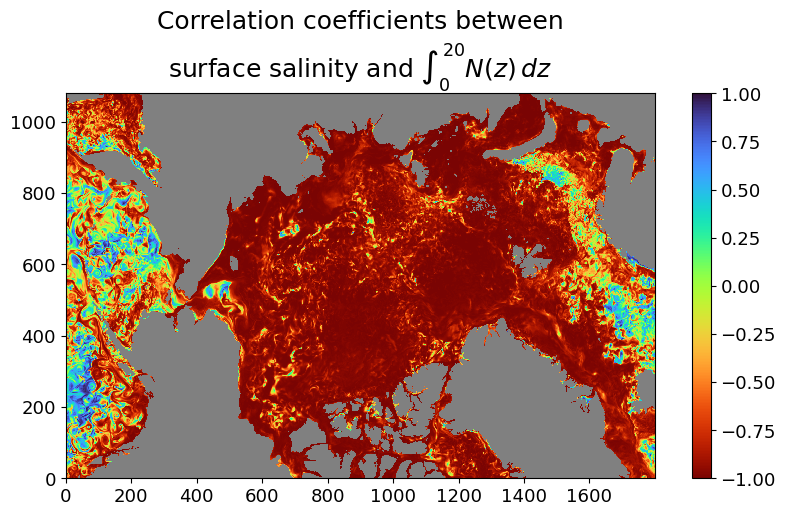

In [36]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_intN20.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Correlation coefficients between\nsurface salinity and $\int_0^{20} N(z) \, dz$', size=18);

## Correlation between SSS and sum($N$) in upper 100 m

In [14]:
# select entire month and only vertical levels we want
# pull out the upper 20 m of data
date = "2019-08"
salt_month = SALT_zarr.SALT.sel(time=date).isel(k=slice(0,22))
temp_month = THETA_zarr.THETA.sel(time=date).isel(k=slice(0,22))

In [15]:
# check depths
salt_month.Z.values

array([ -0.5  ,  -1.57 ,  -2.79 ,  -4.185,  -5.78 ,  -7.595,  -9.66 ,
       -12.01 , -14.68 , -17.705, -21.125, -24.99 , -29.345, -34.24 ,
       -39.725, -45.855, -52.69 , -60.28 , -68.685, -77.965, -88.175,
       -99.37 ], dtype=float32)

In [16]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=slice(0,22)).Z, HH_grid.YC).compute()

In [17]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,   1.58346296,   2.8139329 ,   4.22091377,
         5.82962441,   7.66024071,   9.74302836,  12.1132969 ,
        14.80635815,  17.85752767,  21.30716931,  25.20573703,
        29.59864862,  34.53637577,  40.06938752,  46.25322558,
        53.14847207,  60.80564481,  69.28536079,  78.64826011,
        88.94996626, 100.246103  ])

In [18]:
# check shape of each dataset
print(np.shape(salt_month))
print(np.shape(temp_month))
print(np.shape(pressure_da))

(31, 22, 1080, 1800)
(31, 22, 1080, 1800)
(22, 1080, 1800)


Note: opting to use practical salinity and in situ temperature here to reduce computational load since these values are effectively identical near the surface

In [19]:
import time

In [20]:
# start time
start_time = time.time()

# Brunt Vaisala Frequency (N^2)
# Buoyancy frequency-squared at pressure midpoints, 1/s^2. 
# The shape along the pressure axis dimension is one less than that of the inputs. (Frequency N is in radians per second.)
# Pressure at midpoints of p, dbar. The array shape matches N2.
N2, p_mid = gsw.Nsquared(salt_month, temp_month, pressure_da, axis=1)

# end time
end_time = time.time()

# calculate elapsed time
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")

MemoryError: Unable to allocate 9.43 GiB for an array with shape (31, 21, 1080, 1800) and data type float64

In [ ]:
N2.shape

In [ ]:
p_mid.shape

In [203]:
# take average across whole domain
p_mid_avg = p_mid.mean(axis=(0,2,3))

In [204]:
p_mid_avg

array([ 1.04555006,  2.20222694,  3.52306898,  5.03333492,  6.75575859,
        8.71560126, 10.94570317, 13.48143171, 16.35815727, 19.6137803 ])

In [211]:
N2_da = xr.DataArray(data=N2,dims=['time','p_mid','j','i'],\
                     coords=dict(p_mid=p_mid_avg,j=abs_salt.j.values,i=abs_salt.i.values,time=abs_salt.time.values))

In [213]:
N_sum20 = np.sqrt(N2_da.sum('p_mid'))

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/xarray/core/computation.py:825: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


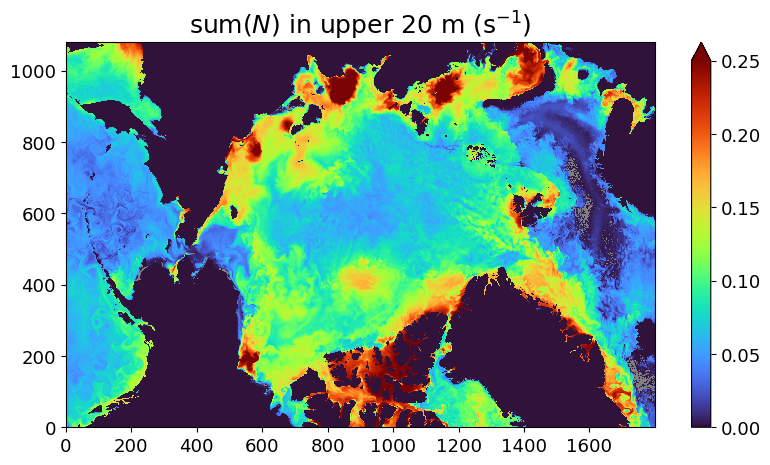

In [221]:
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=[9.5,5])
N_sum20.sel(time="2019-08-15").plot(ax=ax,cmap='turbo', vmin=0, vmax=0.25);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("sum($N$) in upper 20 m (s$^{-1}$)",size=18);

In [224]:
corr_sumN20 = xr.corr(abs_salt.isel(k=0), N_sum20, dim='time').compute()

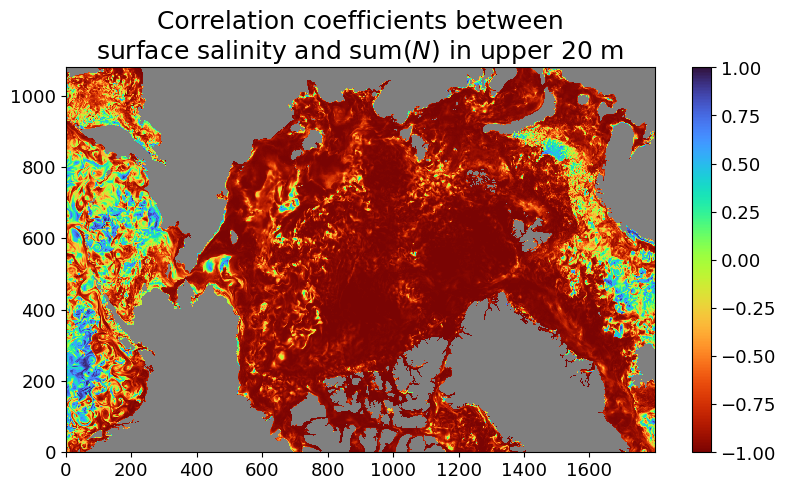

In [225]:
# same plot as above - just plotting to sanity check that absolute salinity is same as practial salinity above
fig, ax = plt.subplots(figsize=[9.5,5])
corr_sumN20.plot(ax=ax,cmap='turbo_r',vmin=-1,vmax=1);
ax.set_facecolor('gray')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title('Correlation coefficients between\nsurface salinity and sum($N$) in upper 20 m', size=18);